**Find which ad is the most effective**

way1 Upper Confidence Bound (UCB)

ex. compare ads click rate - 4 has the most access rate bc it used beautiful picture in ad

way2 Thompson Sampling

ex. compare ads click rate - 4 has the most access rate bc it used beautiful picture in ad

In [2]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from google.colab import drive
sc=StandardScaler()#x=(x-μ)/σ μ:mean σ:stev
drive.mount('/content/drive')
f7=pd.read_csv('/content/drive/MyDrive/ml/asset/ad_clickrate.csv')
f3=pd.read_csv('/content/drive/MyDrive/ml/asset/salary_exp.csv')

Mounted at /content/drive


**1 Upper Confidence Bound (UCB)**

ex. compare ads click rate - 4 has the most access rate bc it used beautiful picture in ad
- use data includes accessed ads per user
clicks/impressions = CTR. For example, if you had 5 clicks and 100 impressions, then your CTR would be 5%

prepared data: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 0, 1, 2, 3, 4, 5, 6, 7, 8, 8, 9, 0, 8, 1, 2, 3, 4, 5, 6, 6, 7, 7, 7, 9, 7, 0, 6, 8, 1, 2, 3, 4, 4, 4, 4, 4, 5, 9, 7, 0, 0, 6, 8, 4, 0, 7, 1, 1, 2, 3, 5, 9, 4, 1, 6, 8, 0, 7, 2, 3, 5, 9, 4, 1, 6, 8, 0, 7, 7, 7, 7, 7, 7, 4, 2, 3, 5, 9, 1, 6, 8, 0, 0, 7, 0, 4, 1, 6, 8, 2, 3, 5, 9, 7, 0, 4, 4, 4, 7, 7, 7, 7, 1, 6, 8, 2, 3, 5, 9, 0, 7, 7, 4, 7, 7, 7, 1, 6, 8, 0, 4, 4, 2, 3, 5, 9, 4, 7, 0, 7, 1, 1, 1, 6, 6, 6, 6, 6, 8, 4, 2, 3, 5, 9, 7, 7, 7, 0, 6, 4, 1, 1, 1, 8, 7, 2, 3, 5, 9, 4, 0, 1, 1, 1, 6, 7, 8, 4, 1, 2, 3, 5, 9, 0, 6, 7, 8, 4, 7, 1, 0, 6, 2, 3, 5, 9, 7, 7, 7, 7, 4, 4, 4, 4, 4, 7, 8, 1, 0, 6, 6, 6, 7, 4, 2, 3, 5, 9, 1, 6, 8, 7, 0, 4, 4, 4, 4, 4, 2, 3, 5, 9, 1, 6, 7, 4, 8, 0, 7, 4, 4, 4, 1, 6, 2, 3, 5, 9, 0, 0, 0, 7, 8, 4, 0, 0, 0, 1, 6, 7, 4, 2, 3, 5, 9, 0, 8, 7, 1, 6, 4, 0, 7, 7, 7, 7, 7, 2, 3, 5, 9, 8, 4, 1, 6, 6, 6, 7, 7, 7, 0, 6, 7, 4, 1, 1, 1, 2, 2, 2, 3, 5, 9, 2, 8, 7, 0, 1, 6, 4, 7, 2, 8, 3, 5, 9, 9, 

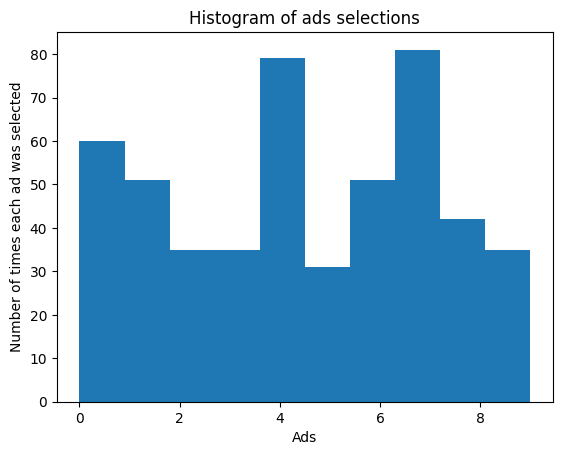

In [3]:
N = 500 #round number compare 10000 and 500
d = 10
ads_selected = []
numbers_of_selections = [0]*d
sums_of_rewards = [0]*d
total_reward = 0
for n in range(0, N):
    ad = 0
    max_upper_bound = 0
    for i in range(0, d):
        if (numbers_of_selections[i] > 0):
            average_reward = sums_of_rewards[i] / numbers_of_selections[i]
            delta_i = math.sqrt(3/2 * math.log(n + 1) / numbers_of_selections[i])
            upper_bound = average_reward + delta_i
        else:
            upper_bound = 1e400
        if upper_bound > max_upper_bound:
            max_upper_bound = upper_bound
            ad = i
    ads_selected.append(ad)
    numbers_of_selections[ad] = numbers_of_selections[ad] + 1
    reward=f7.values[n, ad]
    sums_of_rewards[ad] = sums_of_rewards[ad] + reward
    total_reward = total_reward + reward
print('prepared data:',ads_selected)
plt.hist(ads_selected)
plt.title('Histogram of ads selections')
plt.xlabel('Ads')
plt.ylabel('Number of times each ad was selected')
plt.show()

**2 Thompson Sampling**

ex. compare ads click rate - 4 has the most access rate bc it used beautiful picture in ad

prepared data: [0, 0, 6, 2, 1, 5, 9, 0, 3, 0, 8, 3, 4, 7, 4, 4, 7, 8, 8, 4, 7, 5, 0, 5, 1, 2, 6, 7, 0, 7, 7, 8, 4, 0, 6, 6, 3, 5, 4, 9, 3, 2, 9, 9, 2, 3, 7, 0, 0, 7, 4, 0, 1, 5, 1, 7, 8, 6, 1, 2, 2, 9, 7, 0, 3, 5, 1, 1, 8, 4, 0, 1, 7, 1, 6, 4, 5, 0, 4, 6, 5, 6, 6, 0, 4, 4, 6, 4, 7, 6, 8, 6, 2, 7, 1, 4, 7, 9, 0, 7, 1, 7, 7, 6, 0, 7, 7, 4, 4, 6, 3, 0, 4, 5, 4, 1, 0, 8, 9, 6, 7, 7, 4, 7, 6, 4, 0, 6, 4, 6, 7, 4, 7, 2, 0, 8, 7, 6, 5, 4, 4, 7, 9, 4, 7, 7, 4, 7, 2, 8, 4, 1, 7, 8, 7, 7, 7, 1, 7, 7, 0, 7, 1, 4, 4, 8, 7, 7, 3, 4, 7, 7, 1, 7, 4, 7, 4, 7, 1, 7, 7, 7, 7, 1, 5, 4, 5, 8, 3, 1, 7, 0, 6, 7, 1, 6, 9, 7, 0, 7, 6, 8, 6, 4, 4, 7, 7, 7, 7, 4, 1, 6, 7, 5, 4, 7, 7, 1, 7, 4, 7, 7, 4, 7, 9, 7, 1, 1, 6, 5, 6, 4, 4, 7, 4, 4, 7, 8, 0, 7, 8, 6, 4, 7, 6, 8, 8, 6, 9, 4, 4, 7, 7, 3, 7, 4, 7, 4, 7, 4, 4, 2, 7, 7, 7, 1, 9, 7, 4, 8, 4, 6, 7, 7, 8, 7, 5, 4, 6, 4, 7, 8, 8, 4, 3, 1, 7, 4, 4, 4, 3, 4, 4, 4, 4, 2, 4, 4, 3, 3, 4, 1, 3, 4, 4, 3, 2, 4, 3, 4, 4, 4, 4, 4, 3, 7, 8, 3, 3, 4, 7, 9, 7, 3, 4, 0, 4, 4, 

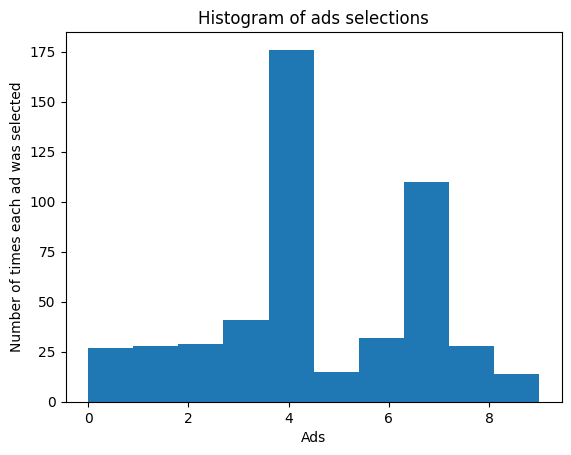

In [4]:
N = 500
d = 10
ads_selected = []
numbers_of_rewards_1 = [0] * d
numbers_of_rewards_0 = [0] * d
total_reward = 0
for n in range(0, N):
    ad = 0
    max_random = 0
    for i in range(0, d):
        random_beta=random.betavariate(numbers_of_rewards_1[i]+1,numbers_of_rewards_0[i]+1)
        if random_beta>max_random:
            max_random=random_beta
            ad=i
    ads_selected.append(ad)
    reward = f7.values[n, ad]
    if reward == 1:
        numbers_of_rewards_1[ad]=numbers_of_rewards_1[ad]+1
    else:
        numbers_of_rewards_0[ad]=numbers_of_rewards_0[ad]+1
    total_reward = total_reward + reward
print('prepared data:',ads_selected)
plt.hist(ads_selected)
plt.title('Histogram of ads selections')
plt.xlabel('Ads')
plt.ylabel('Number of times each ad was selected')
plt.show()